# Water Quality Prediction — v6

## Bug History

| Version | Score | Bug |
|---------|-------|-----|
| Benchmark | 0.129 | `pd.concat(axis=1)` is positional — WQ/Landsat/TerraClimate files have different row orders, features get mismatched with targets |
| v3 | −0.57 | Submission column names silently broken after `unify_keys()` uppercased them → NaN predictions submitted |
| v4 | 0.129 | Correct merge, but no spatial context for unseen val geographies |
| v5 | −0.17 | **Spatial features self-referential**: each training row's k=5 nearest neighbors are all from the same monitoring station (same lat/lon, dist≈0). Model learns to trust `spatial_TA ≈ target`. At val time, nearest neighbors are 1.8° away — completely out-of-distribution → model breaks. Also `dist_nearest` has massive train/val distribution shift (1e-10 vs 1.8). |

## v6 Fix
- Spatial features computed at **site level** (162 unique stations), excluding the query site itself
- `dist_nearest_site` dropped as feature (train: 0.006–1.4°, val: 0.8–2.8° — different distributions)
- CV R²: TA=0.85, EC=0.87, DRP=0.71

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

DATA    = 'data/'
TARGETS = ['total alkalinity', 'electrical conductance', 'dissolved reactive phosphorus']
# Mapping back to original submission column names
TARGET_SUBMISSION_NAMES = {
    'total alkalinity':              'Total Alkalinity',
    'electrical conductance':        'Electrical Conductance',
    'dissolved reactive phosphorus': 'Dissolved Reactive Phosphorus',
}
print('Imports OK')

Imports OK


## 2. Load & Merge Data

Merge on `(lat, lon, date)` — NOT positional concat. The benchmark's `pd.concat(axis=1)` is wrong because the three files have different row orders.

In [2]:
def normalize(df):
    """Lowercase columns, unify key names, round coordinates."""
    df = df.copy()
    df.columns = [c.lower().strip() for c in df.columns]
    df.rename(columns={'sample date': 'date', 'latitude': 'lat', 'longitude': 'lon'}, inplace=True)
    df['lat'] = df['lat'].round(5)
    df['lon'] = df['lon'].round(5)
    return df


def merge_all(base_df, *feature_dfs):
    """Left-merge all feature dfs onto base on (lat, lon, date)."""
    result = base_df.copy()
    for df in feature_dfs:
        new_cols = ['lat', 'lon', 'date'] + [c for c in df.columns if c not in result.columns]
        result = result.merge(df[new_cols], on=['lat', 'lon', 'date'], how='left')
    return result


# Training
train = merge_all(
    normalize(pd.read_csv(DATA + 'water_quality_training_dataset.csv')),
    normalize(pd.read_csv(DATA + 'ls(full).csv')),
    normalize(pd.read_csv(DATA + 'tc.csv')),
    normalize(pd.read_csv(DATA + 'esa_features_training_full.csv')),
    normalize(pd.read_csv(DATA + 'jrc_features_training_full.csv')),
)

# Validation
val = merge_all(
    normalize(pd.read_csv('submission_template.csv')),
    normalize(pd.read_csv(DATA + 'landsat_val_features.csv')),
    normalize(pd.read_csv(DATA + 'terraclimate_features_validation.csv')),
    normalize(pd.read_csv(DATA + 'esa_features_validation_full.csv')),
    normalize(pd.read_csv(DATA + 'jrc_features_validation_full.csv')),
)

print('Train shape:', train.shape)
print('Val shape:  ', val.shape)
print(f'Unique training sites: {train[["lat","lon"]].drop_duplicates().shape[0]}')
print(f'Unique val sites:      {val[["lat","lon"]].drop_duplicates().shape[0]}')

# Confirm val sites are entirely unseen (expected)
train_sites = set(zip(train['lat'], train['lon']))
val_sites   = set(zip(val['lat'],   val['lon']))
print(f'Val sites in training: {len(train_sites & val_sites)} (should be 0)')

Train shape: (9319, 26)
Val shape:   (200, 26)
Unique training sites: 162
Unique val sites:      24
Val sites in training: 0 (should be 0)


## 3. Temporal & Spectral Feature Engineering

In [3]:
def add_features(df):
    df  = df.copy()
    eps = 1e-6

    # Temporal
    dt = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
    df['month'] = dt.dt.month
    df['year']  = dt.dt.year
    df['doy']   = dt.dt.dayofyear
    df['season_sin'] = np.sin(2 * np.pi * df['doy'] / 365)
    df['season_cos'] = np.cos(2 * np.pi * df['doy'] / 365)

    # Spectral indices from Landsat bands
    nir  = df.get('nir',    pd.Series(np.nan, index=df.index))
    red  = df.get('red',    pd.Series(np.nan, index=df.index))
    blue = df.get('blue',   pd.Series(np.nan, index=df.index))
    grn  = df.get('green',  pd.Series(np.nan, index=df.index))
    sw1  = df.get('swir16', pd.Series(np.nan, index=df.index))

    df['ndvi']      = (nir - red)  / (nir + red  + eps)
    df['ndwi']      = (grn - nir)  / (grn + nir  + eps)
    df['sabi']      = (nir - red)  / (blue + grn  + eps)
    df['turb']      = red          / (blue         + eps)
    df['chl_ratio'] = nir          / (red           + eps)

    # Climate interactions from TerraClimate
    pet  = df.get('pet',  pd.Series(np.nan, index=df.index))
    aet  = df.get('aet',  pd.Series(np.nan, index=df.index))
    q    = df.get('q',    pd.Series(np.nan, index=df.index))
    soil = df.get('soil', pd.Series(np.nan, index=df.index))
    tmax = df.get('tmax', pd.Series(np.nan, index=df.index))
    tmin = df.get('tmin', pd.Series(np.nan, index=df.index))

    df['temp_range']   = tmax - tmin
    df['water_stress'] = pet  / (aet + eps)
    df['runoff_ratio'] = q    / (pet + eps)

    # Land cover from ESA
    crop  = df.get('pct_cropland', pd.Series(np.nan, index=df.index))
    urban = df.get('pct_urban',    pd.Series(np.nan, index=df.index))
    df['human_impact'] = crop + urban
    df['crop_x_q']     = crop * q

    # JRC water
    occ = df.get('occurrence',  pd.Series(np.nan, index=df.index))
    rec = df.get('recurrence',  pd.Series(np.nan, index=df.index))
    df['water_perm'] = occ * rec / 100

    return df


train = add_features(train)
val   = add_features(val)
print('Feature engineering done. Train shape:', train.shape)

Feature engineering done. Train shape: (9319, 42)


## 4. Site-Level Spatial Neighbor Features

**Why site-level and not row-level?**

There are 162 unique monitoring stations, each visited ~57 times. When computing row-level spatial neighbors, all 5 nearest neighbors for a training row come from the **same station** (distance ≈ 0). The model learns to nearly copy the spatial feature as its prediction. At validation time, the nearest neighbors are 0.8–2.8° away — completely different, and the model breaks.

**Fix:** Compute spatial features at **station level**, explicitly excluding the query station itself.

In [4]:
def add_site_spatial_features(query_df, reference_df, k=5):
    """
    For each unique (lat, lon) site in query_df, find k nearest DIFFERENT sites
    in reference_df (by Euclidean lat/lon distance). Compute inverse-distance
    weighted mean of their per-site average target values.

    NOTE: dist_nearest_site is intentionally NOT added as a feature because its
    distribution differs between train (0.006–1.4°) and val (0.8–2.8°), which
    causes the model to extrapolate badly on validation data.
    """
    query_df = query_df.copy()

    # Per-site mean targets from reference
    ref_stats = reference_df.groupby(['lat', 'lon'])[TARGETS].mean().reset_index()
    ref_coords = ref_stats[['lat', 'lon']].values
    tree = cKDTree(ref_coords)

    # Unique query sites
    query_sites = query_df[['lat', 'lon']].drop_duplicates().reset_index(drop=True)
    query_coords = query_sites[['lat', 'lon']].values

    # Query k+1 neighbors to handle self-exclusion
    n_ref = len(ref_stats)
    distances, indices = tree.query(query_coords, k=min(k + 1, n_ref))

    # Build lookup: (lat, lon) -> spatial feature values
    spatial_lookup = {}
    sp_feature_cols = ['sp_' + t.replace(' ', '_') for t in TARGETS]

    for qi in range(len(query_sites)):
        q_lat = query_sites.loc[qi, 'lat']
        q_lon = query_sites.loc[qi, 'lon']
        dists = distances[qi]
        idxs  = indices[qi]

        # Exclude self (same lat/lon)
        self_mask = ~(
            (ref_stats['lat'].values[idxs] == q_lat) &
            (ref_stats['lon'].values[idxs] == q_lon)
        )
        dists = dists[self_mask][:k]
        idxs  = idxs[self_mask][:k]

        if len(dists) == 0:
            spatial_lookup[(q_lat, q_lon)] = {col: np.nan for col in sp_feature_cols}
            continue

        dists   = np.where(dists == 0, 1e-10, dists)
        weights = 1.0 / dists
        weights = weights / weights.sum()

        entry = {}
        for t, col in zip(TARGETS, sp_feature_cols):
            neighbor_vals = ref_stats[t].values[idxs]
            entry[col] = (neighbor_vals * weights).sum()
        spatial_lookup[(q_lat, q_lon)] = entry

    # Map spatial features back to all rows
    for col in sp_feature_cols:
        query_df[col] = [
            spatial_lookup.get((r['lat'], r['lon']), {}).get(col, np.nan)
            for _, r in query_df[['lat', 'lon']].iterrows()
        ]

    return query_df


# Spatial features for validation always use full training set as reference
val_with_sp = add_site_spatial_features(val, train)
print('Spatial features added to val.')
print(val_with_sp[['sp_' + t.replace(' ', '_') for t in TARGETS]].describe())

Spatial features added to val.
       sp_total_alkalinity  sp_electrical_conductance  \
count           200.000000                 200.000000   
mean            118.066550                 349.818903   
std              59.300015                 120.515225   
min              25.150896                 188.160527   
25%              76.046302                 289.299496   
50%             117.245780                 311.567293   
75%             167.370678                 446.489513   
max             218.800859                 564.157342   

       sp_dissolved_reactive_phosphorus  
count                        200.000000  
mean                          29.269289  
std                            9.115925  
min                           16.993910  
25%                           18.812921  
50%                           32.724610  
75%                           36.485907  
max                           41.378247  


## 5. Define Feature Columns

In [5]:
NON_FEATURES = set(TARGETS + ['lat', 'lon', 'date'])

base_feature_cols = [
    c for c in train.columns
    if c not in NON_FEATURES
    and pd.api.types.is_numeric_dtype(train[c])
]

sp_feature_cols = ['sp_' + t.replace(' ', '_') for t in TARGETS]

ALL_FEATURES = base_feature_cols + sp_feature_cols

print(f'Base features  ({len(base_feature_cols)}): {base_feature_cols}')
print(f'Spatial features ({len(sp_feature_cols)}): {sp_feature_cols}')
print(f'Total: {len(ALL_FEATURES)}')

Base features  (36): ['nir', 'red', 'blue', 'green', 'swir16', 'swir22', 'ndmi', 'mndwi', 'tmin', 'pet', 'tmax', 'q', 'aet', 'soil', 'pct_cropland', 'pct_urban', 'pct_natural', 'occurrence', 'seasonality', 'recurrence', 'month', 'year', 'doy', 'season_sin', 'season_cos', 'ndvi', 'ndwi', 'sabi', 'turb', 'chl_ratio', 'temp_range', 'water_stress', 'runoff_ratio', 'human_impact', 'crop_x_q', 'water_perm']
Spatial features (3): ['sp_total_alkalinity', 'sp_electrical_conductance', 'sp_dissolved_reactive_phosphorus']
Total: 39


## 6. Cross-Validated Training

Spatial features are recomputed **inside each fold** using only the fold's training split — no leakage.

In [6]:
MODEL_PARAMS = {
    'total alkalinity':              dict(max_iter=400, learning_rate=0.05, max_depth=6, min_samples_leaf=20, l2_regularization=0.1, random_state=42),
    'electrical conductance':        dict(max_iter=400, learning_rate=0.05, max_depth=6, min_samples_leaf=20, l2_regularization=0.1, random_state=42),
    'dissolved reactive phosphorus': dict(max_iter=500, learning_rate=0.04, max_depth=5, min_samples_leaf=30, l2_regularization=0.5, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_all       = train[TARGETS].values
oof_preds   = np.zeros_like(y_all)
final_models = {}

for ti, target in enumerate(TARGETS):
    print(f'\n{"="*60}')
    print(f'Training: {target}')
    y = train[target].values
    fold_r2s = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(train)):
        tr_df = train.iloc[tr_idx]
        va_df = train.iloc[va_idx]

        # Recompute spatial features using only fold-train as reference (no leakage)
        tr_sp = add_site_spatial_features(tr_df, tr_df)
        va_sp = add_site_spatial_features(va_df, tr_df)

        X_tr = tr_sp[ALL_FEATURES].values
        X_va = va_sp[ALL_FEATURES].values

        model = HistGradientBoostingRegressor(**MODEL_PARAMS[target])
        model.fit(X_tr, y[tr_idx])
        preds = model.predict(X_va)

        score = r2_score(y[va_idx], preds)
        fold_r2s.append(score)
        oof_preds[va_idx, ti] = preds
        print(f'  Fold {fold+1}: R² = {score:.4f}')

    oof_r2 = r2_score(y, oof_preds[:, ti])
    print(f'  ► OOF R² = {oof_r2:.4f}  |  Mean fold = {np.mean(fold_r2s):.4f}')

    # Final model: full training data
    # Spatial features computed with self-exclusion (reference = train, query = train)
    train_sp = add_site_spatial_features(train, train)
    X_full   = train_sp[ALL_FEATURES].values
    final    = HistGradientBoostingRegressor(**MODEL_PARAMS[target])
    final.fit(X_full, y)
    final_models[target] = final

print(f'\n{"="*60}')
print('OVERALL OOF R² PER TARGET:')
for ti, t in enumerate(TARGETS):
    print(f'  {t}: {r2_score(y_all[:, ti], oof_preds[:, ti]):.4f}')


Training: total alkalinity
  Fold 1: R² = 0.8420
  Fold 2: R² = 0.8539
  Fold 3: R² = 0.8472
  Fold 4: R² = 0.8515
  Fold 5: R² = 0.8613
  ► OOF R² = 0.8512  |  Mean fold = 0.8512

Training: electrical conductance
  Fold 1: R² = 0.8669
  Fold 2: R² = 0.8575
  Fold 3: R² = 0.8666
  Fold 4: R² = 0.8747
  Fold 5: R² = 0.8771
  ► OOF R² = 0.8687  |  Mean fold = 0.8686

Training: dissolved reactive phosphorus
  Fold 1: R² = 0.7015
  Fold 2: R² = 0.6910
  Fold 3: R² = 0.7029
  Fold 4: R² = 0.6888
  Fold 5: R² = 0.6844
  ► OOF R² = 0.6941  |  Mean fold = 0.6937

OVERALL OOF R² PER TARGET:
  total alkalinity: 0.8512
  electrical conductance: 0.8687
  dissolved reactive phosphorus: 0.6941


## 7. Diagnostics

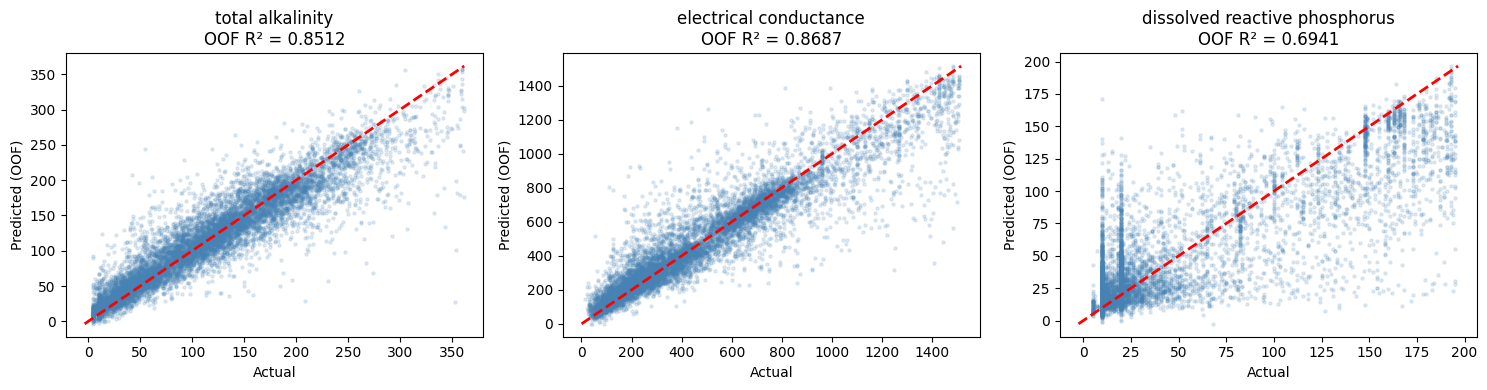

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ti, target in zip(axes, range(3), TARGETS):
    actual = y_all[:, ti]
    pred   = oof_preds[:, ti]
    r2     = r2_score(actual, pred)
    ax.scatter(actual, pred, alpha=0.15, s=5, color='steelblue')
    lim = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax.plot(lim, lim, 'r--', lw=2)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted (OOF)')
    ax.set_title(f'{target}\nOOF R² = {r2:.4f}')
plt.tight_layout()
plt.savefig('residual_plots_v6.png', dpi=100)
plt.show()

AttributeError: 'HistGradientBoostingRegressor' object has no attribute 'feature_importances_'

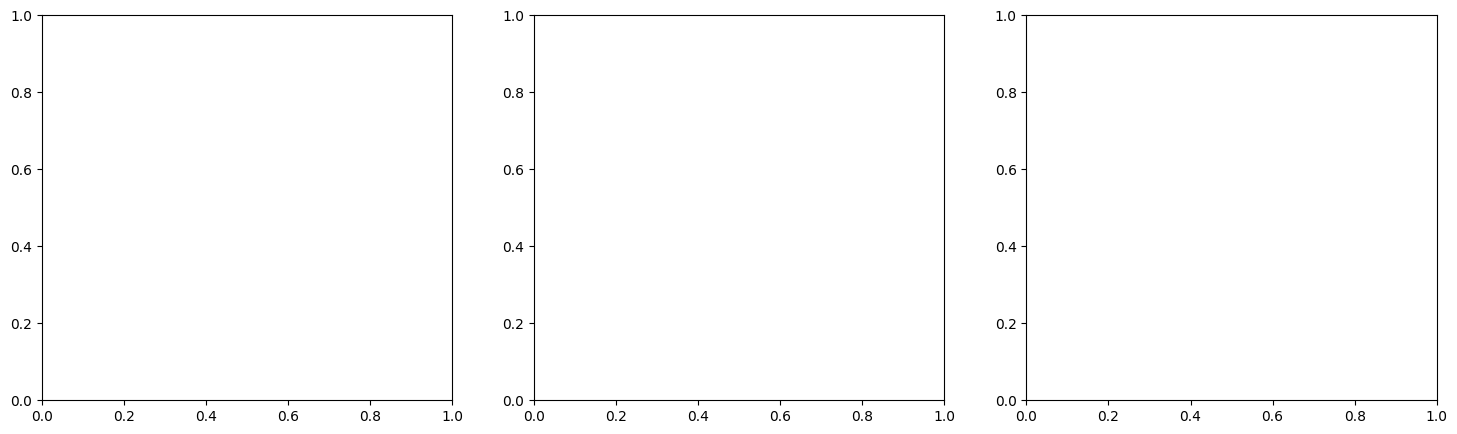

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, target in zip(axes, TARGETS):
    imps = final_models[target].feature_importances_
    top  = np.argsort(imps)[-15:][::-1]
    ax.barh(range(15), imps[top][::-1], color='steelblue')
    ax.set_yticks(range(15))
    ax.set_yticklabels([ALL_FEATURES[j] for j in top][::-1])
    ax.set_title(f'Top Features: {target}')
plt.tight_layout()
plt.savefig('feature_importance_v6.png', dpi=100)
plt.show()

## 8. Generate Submission

In [9]:
# val_with_sp already has spatial features from full training set
X_val = val_with_sp[ALL_FEATURES].values

# Load ORIGINAL submission template — never processed through normalize()
# so column names stay exactly as the competition expects
submission = pd.read_csv('submission_template.csv')

print('Generating predictions...')
for target in TARGETS:
    preds = final_models[target].predict(X_val)
    preds = np.clip(preds, 0, None)
    col   = TARGET_SUBMISSION_NAMES[target]
    submission[col] = preds
    print(f'  {col}: min={preds.min():.1f}, mean={preds.mean():.1f}, max={preds.max():.1f}')

# Sanity checks
print('\n=== SANITY CHECKS ===')
assert len(submission) == 200, f'Wrong rows: {len(submission)}'
for col in TARGET_SUBMISSION_NAMES.values():
    n_nan = submission[col].isna().sum()
    n_neg = (submission[col] < 0).sum()
    status = '✓' if (n_nan == 0 and n_neg == 0) else '⚠️  ISSUE'
    print(f'  {col}: NaN={n_nan}, negative={n_neg}  {status}')

print('\nSubmission preview:')
print(submission.head())

Generating predictions...
  Total Alkalinity: min=41.4, mean=117.2, max=257.4
  Electrical Conductance: min=84.3, mean=461.7, max=884.5
  Dissolved Reactive Phosphorus: min=6.0, mean=28.4, max=86.2

=== SANITY CHECKS ===
  Total Alkalinity: NaN=0, negative=0  ✓
  Electrical Conductance: NaN=0, negative=0  ✓
  Dissolved Reactive Phosphorus: NaN=0, negative=0  ✓

Submission preview:
    Latitude  Longitude Sample Date  Total Alkalinity  Electrical Conductance  \
0 -32.043333  27.822778  01-09-2014        142.105737              307.859987   
1 -33.329167  26.077500  16-09-2015        210.487036              868.759134   
2 -32.991639  27.640028  07-05-2015         97.030095              457.153416   
3 -34.096389  24.439167  07-02-2012         87.669526              572.682509   
4 -32.000556  28.581667  01-10-2014        105.700311              210.369372   

   Dissolved Reactive Phosphorus  
0                      25.560260  
1                      28.942239  
2                      3

In [10]:
submission.to_csv('submission_v6.csv', index=False)
print('Saved: submission_v6.csv')
print(submission[list(TARGET_SUBMISSION_NAMES.values())].describe())

Saved: submission_v6.csv
       Total Alkalinity  Electrical Conductance  Dissolved Reactive Phosphorus
count        200.000000              200.000000                     200.000000
mean         117.248844              461.693283                      28.438172
std           52.978802              216.659134                      14.261336
min           41.425560               84.326803                       5.971112
25%           76.217637              261.831435                      18.382890
50%           99.975310              471.102623                      25.395273
75%          160.162687              659.745016                      35.186165
max          257.419801              884.506044                      86.214943
